# Quickstart: NOAA HRRR analysis, virtual - dynamical.org Icechunk Zarr

NOAA's High-Resolution Rapid Refresh (HRRR) is a convection-allowing model covering the contiguous United States at 3 km, fine enough to resolve small-scale weather patterns.

This virtual analysis dataset is the model's best estimate of the atmosphere at each hour and is optimized for spatial/map-oriented access patterns. For long time series at a point, use the time-optimized [NOAA HRRR analysis](https://dynamical.org/catalog/noaa-hrrr-analysis/) instead.

Dataset documentation: https://dynamical.org/catalog/noaa-hrrr-analysis-virtual/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy rioxarray

In [2]:
from urllib.parse import urlparse

import gribberish.zarr  # noqa: F401  registers the codec that decodes the virtual GRIB references
import icechunk
import xarray as xr

# When the STAC collection is published, replace this cell with:
#     import dynamical_catalog
#
#     ds = dynamical_catalog.open("noaa-hrrr-analysis-virtual", chunks=None)
#     ds
STORE_URL = "s3://dynamical-noaa-hrrr/noaa-hrrr-analysis-virtual/v0.1.0.icechunk"


def open_hrrr_analysis(group: str | None = None) -> xr.Dataset:
    url = urlparse(STORE_URL)
    repo = icechunk.Repository.open(
        icechunk.s3_storage(bucket=url.netloc, prefix=url.path.strip("/"), region="us-west-2", anonymous=True),
        authorize_virtual_chunk_access=icechunk.containers_credentials(
            {"s3://noaa-hrrr-bdp-pds": icechunk.s3_anonymous_credentials()}  # NOAA's GRIB archive
        ),
    )
    return xr.open_zarr(repo.readonly_session("main").store, group=group, chunks=None)


ds = open_hrrr_analysis()
ds

<xarray.Dataset> Size: 226TB
Dimensions:                                                          (
                                                                      time: 104373,
                                                                      y: 1059,
                                                                      x: 1799)
Coordinates:
  * time                                                             (time) datetime64[ns] 835kB ...
  * y                                                                (y) float64 8kB ...
  * x                                                                (x) float64 14kB ...
    latitude                                                         (y, x) float32 8MB ...
    longitude                                                        (y, x) float32 8MB ...
    spatial_ref                                                      int64 8B ...
Data variables: (12/142)
    aerosol_optical_thickness_atmosphere                             (time, y, x) float64 2TB ...
    categorical_freezing_rain_surface                                (time, y, x) float64 2TB ...
    brightness_temperature_channel_113                               (time, y, x) float64 2TB ...
    brightness_temperature_channel_123                               (time, y, x) float64 2TB ...
    brightness_temperature_channel_124                               (time, y, x) float64 2TB ...
    categorical_rain_surface                                         (time, y, x) float64 2TB ...
    ...                                                               ...
    wind_u_10m                                                       (time, y, x) float64 2TB ...
    wind_v_10m                                                       (time, y, x) float64 2TB ...
    visible_diffuse_downward_solar_flux_surface                      (time, y, x) float64 2TB ...
    wind_u_80m                                                       (time, y, x) float64 2TB ...
    wind_v_80m                                                       (time, y, x) float64 2TB ...
    wind_gust_surface                                                (time, y, x) float64 2TB ...
Attributes:
    dataset_id:          noaa-hrrr-analysis-virtual
    dataset_version:     0.1.0
    name:                NOAA HRRR analysis, virtual
    description:         Analysis data from the High-Resolution Rapid Refresh...
    attribution:         NOAA NWS NCEP HRRR data processed by dynamical.org f...
    license:             CC-BY-4.0
    spatial_domain:      Continental United States
    spatial_resolution:  3 km
    time_domain:         2014-10-01 00:00:00 UTC to Present
    time_resolution:     1 hour

Variables on vertical levels live in the `pressure_level` and `model_level` groups: `open_hrrr_analysis(group="pressure_level")`.

### A map and a time series

Let's first plot a map at a point in time.

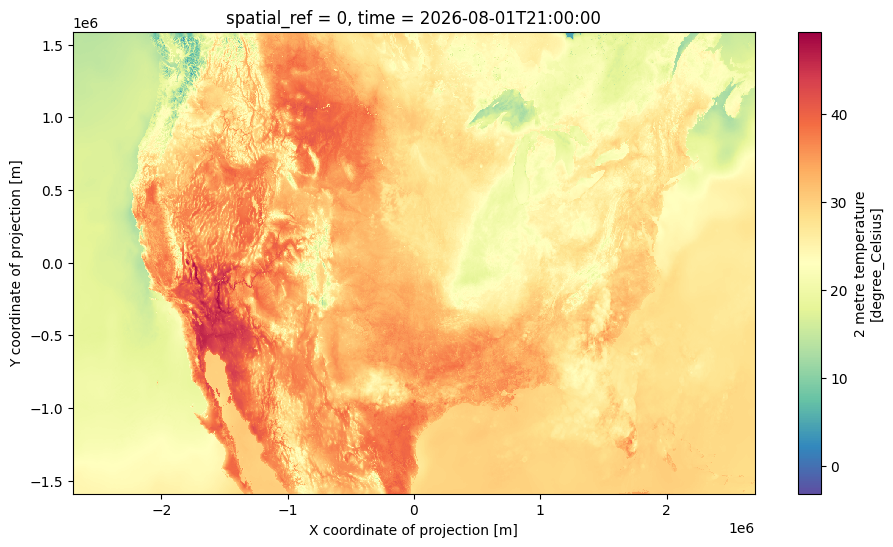

In [3]:
(
    ds["temperature_2m"]
    .sel(time="2026-08-01T21")
    .plot(figsize=(11, 6), cmap="Spectral_r", center=False)
)

Now let's plot a time series at a specific location.

Here we use `pyproj` to convert longitude and latitude into the x, y coordinates of HRRR's native coordinate reference system.

This time window covers the arctic front that crossed the Midwest on 22 December 2022: Chicago falls 19 °C in twelve hours as it passes.

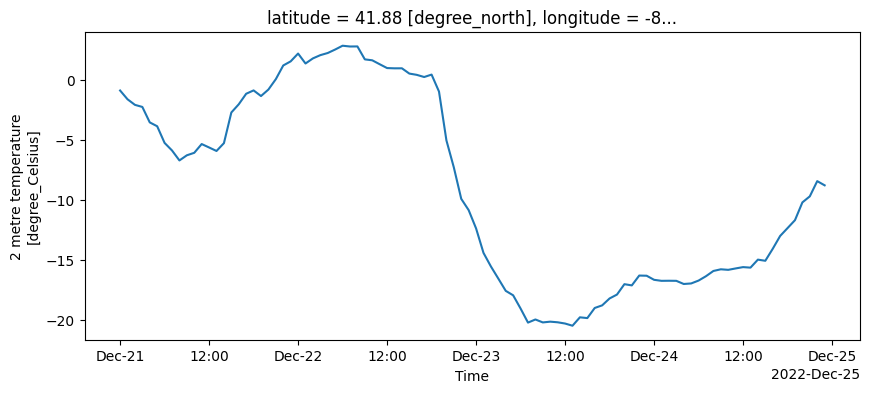

In [4]:
import rioxarray  # noqa: F401  enables the .rio accessor
from pyproj import Transformer

lon_lat_to_grid = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
chicago_x, chicago_y = lon_lat_to_grid.transform(-87.63, 41.88)  # Chicago, IL

(
    ds["temperature_2m"]
    .sel(time=slice("2022-12-21", "2022-12-24"))
    .sel(x=chicago_x, y=chicago_y, method="nearest")
    .plot(figsize=(10, 4))
)

In [5]:
# Brief interlude: HRRR's projection, plus a helper to draw state borders and coastlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

grid = ds.spatial_ref.attrs
hrrr_proj = ccrs.LambertConformal(
    central_longitude=grid["longitude_of_central_meridian"],
    central_latitude=grid["latitude_of_projection_origin"],
    standard_parallels=grid["standard_parallel"],
    globe=ccrs.Globe(semimajor_axis=grid["semi_major_axis"], semiminor_axis=grid["semi_minor_axis"]),
)


def borders(ax):
    ax.add_feature(cfeature.STATES, edgecolor="0.35", linewidth=0.4)
    ax.coastlines(resolution="50m", linewidth=0.5, color="0.25")

### How far did the June 2023 Canadian wildfire smoke reach?

Smoke from Quebec pushed south over New York and Pennsylvania on 7 June 2023, and air quality reached Code Purple in New York City and Philadelphia. HRRR's `mass_density_8m` is smoke concentration 8 m above the surface, roughly breathing height.

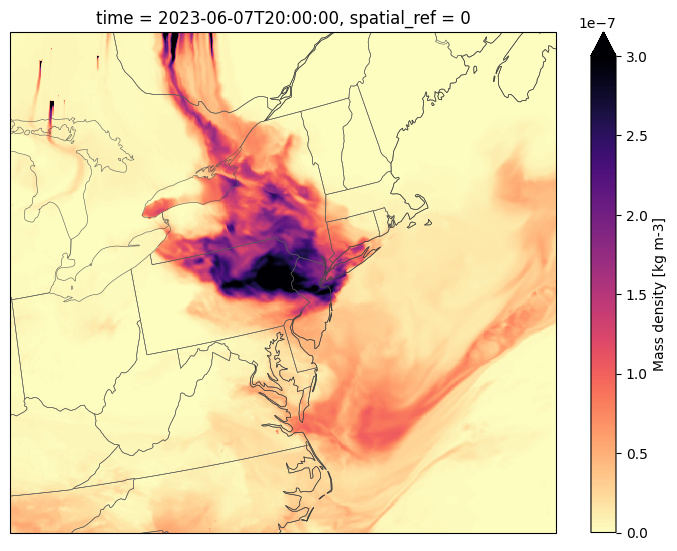

In [6]:
smoke = (
    ds["mass_density_8m"]
    .sel(time="2023-06-07T20")
    .rio.clip_box(-84, 35.5, -68, 46, crs="EPSG:4326")
)

fig, ax = plt.subplots(figsize=(9, 6.5), subplot_kw={"projection": hrrr_proj})
smoke.plot(ax=ax, transform=hrrr_proj, cmap="magma_r", vmax=0.3e-6)
borders(ax)

### How narrow were the lake-effect snow bands near Buffalo?

Air near −10 °C aloft crossed a record-warm Lake Erie between 16 and 20 November 2022. Buffalo set a daily snowfall record of 21.5 inches (~55 cm).

Summing three days of hourly precipitation, the Lake Erie band peaks at 132 mm of liquid equivalent in a strip only a few tens of kilometers wide.

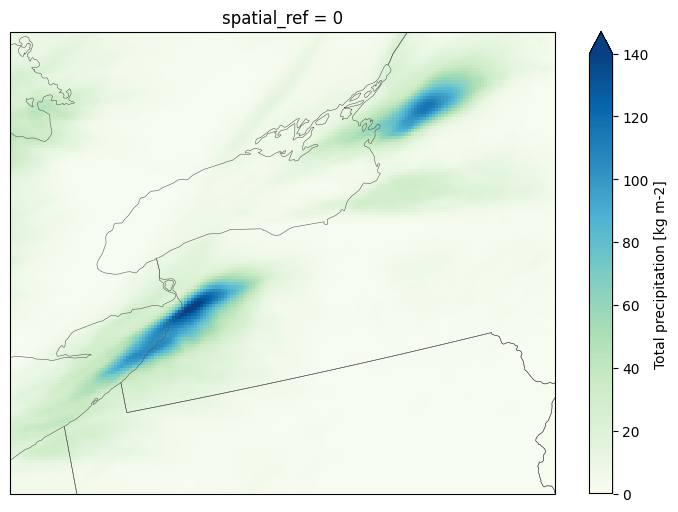

In [7]:
event_total = (
    ds["total_precipitation_surface"]
    .rio.clip_box(-80.5, 41.4, -74.8, 44.6, crs="EPSG:4326")
    .sel(time=slice("2022-11-17", "2022-11-19"))
    .sum("time")
)

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": hrrr_proj})
event_total.plot(ax=ax, transform=hrrr_proj, cmap="GnBu", vmax=140)
borders(ax)

### Animated: the 10 August 2020 derecho crossing the Corn Belt

NWS Des Moines describes it as an event "often compared to an inland hurricane". NWS Quad Cities put the highest measured gust at 126 mph (~200 km/h) at Atkins, Iowa, and estimated maximum winds near 140 mph (~225 km/h).

On the left is HRRR's simulated radar. On the right, a running maximum of each hour's peak 10 m wind.

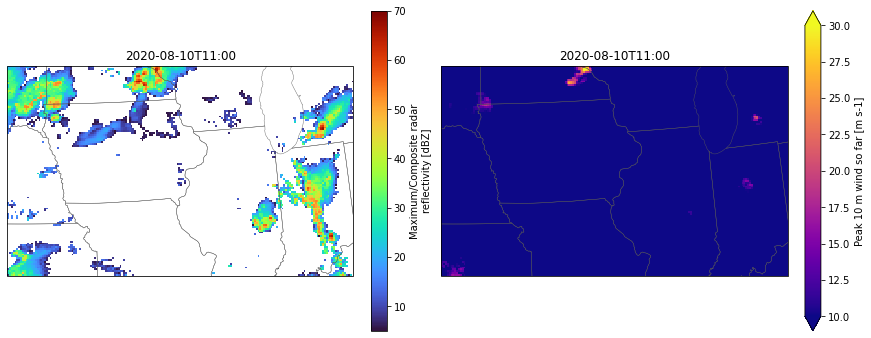

In [8]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

derecho = (
    ds[["composite_reflectivity", "maximum_wind_speed_10m"]]
    .sel(time=slice("2020-08-10T11", "2020-08-11T00"))
    .rio.clip_box(-98, 38.5, -85, 44, crs="EPSG:4326")
    .coarsen(x=2, y=2, boundary="trim").max()
    .drop_vars("spatial_ref")
)
reflectivity = derecho["composite_reflectivity"].where(derecho["composite_reflectivity"] > 5)

# Running maximum of each hour's peak 10 m wind
wind = derecho["maximum_wind_speed_10m"]
wind = wind.copy(data=np.maximum.accumulate(wind.values, axis=wind.get_axis_num("time")))
wind.attrs = {"long_name": "Peak 10 m wind so far", "units": "m s-1"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), dpi=72, subplot_kw={"projection": hrrr_proj}, constrained_layout=True)

refl_plot = reflectivity[0].plot(ax=axes[0], transform=hrrr_proj, cmap="turbo", vmin=5, vmax=70)
wind_plot = wind[0].plot(ax=axes[1], transform=hrrr_proj, cmap="plasma", vmin=10, vmax=30)

for ax in axes:
    borders(ax)

def draw_frame(i):
    refl_plot.set_array(reflectivity[i].values.ravel())
    wind_plot.set_array(wind[i].values.ravel())
    time = str(reflectivity.time.values[i])[:16]
    axes[0].set_title(time)
    axes[1].set_title(time)


animation = FuncAnimation(fig, draw_frame, frames=reflectivity.sizes["time"], interval=450)
HTML(animation.to_jshtml())

### Community challenge

- **Map where a fine-scale phenomenon actually lives.** Count the hours each cell exceeds a threshold — updraft helicity above 75 m² s⁻², near-surface smoke above 35 µg m⁻³, visibility below 1 km. How does the annual count change over the years?
- **Verify a forecast against the analysis.** Read the same field and valid time from the [18 hour](https://dynamical.org/catalog/noaa-hrrr-forecast-18-hour-virtual/) or [48 hour](https://dynamical.org/catalog/noaa-hrrr-forecast-48-hour-virtual/) virtual forecast archives and map the difference. Does error grow fastest where the terrain is steepest?
- **Check the analysis against radar.** [NOAA MRMS](https://dynamical.org/catalog/noaa-mrms-conus-analysis-hourly/) gives observed hourly precipitation on a comparable grid. Where do the two disagree, and is it systematic by season or region?
- **Go vertical.** The `model_level` group carries turbulent kinetic energy and hydrometeor number concentrations on all 50 native levels — enough to reconstruct a storm's structure at the moment it matters.